# Annotation Quality & Model Performance Bound

Four human annotators (E, F, G, H) independently labelled a subset of ants/v3 videos.
We measure their pairwise agreement and use it to derive a **hard upper bound on model balanced accuracy**:
no model evaluated on these annotations can exceed human-level agreement.

In [1]:
import sys, yaml
from pathlib import Path
from itertools import combinations
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make src importable
ROOT = Path('../../').resolve()
sys.path.insert(0, str(ROOT / 'src'))

from dataset.get_annotations import AnnotationExtractor
from utils import noise_bound, mixed_ba_bound
from visualize import plot_iaba_heatmap, plot_disagreement_temporal

print('ROOT:', ROOT)

ROOT: /nfs/scistore19/locatgrp/rcadei/artificial-causal-inference


In [2]:
# ── USER CONFIGURATION ──────────────────────────────────────────────────────

OUTCOMES_TO_ANALYZE  = ['Y2F', 'B2F']   # None = all v3 outcomes
INCLUDE_AVG_OUTCOME  = True              # add AVG(Y2F,B2F) summary row
N_DISAGREE_EXAMPLES  = 10               # disagreement frames to show per outcome

RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

FRAME_ROOT = ROOT / 'dataset' / 'ants' / 'v3' / 'frames' / 'full'
# ─────────────────────────────────────────────────────────────────────────────

## 1. Setup

Load v3 config, discover multi-annotated videos, and extract per-frame labels.

In [3]:
CONFIG_PATH = ROOT / 'configs' / 'dataset' / 'ants' / 'v3.yaml'
with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

ALL_OUTCOMES = cfg['outcomes']        # ['Y2F', 'B2F', 'FOL', 'YOL', 'BOL']
OUTCOME_MAP  = cfg['outcome_mapping']

# Filter to selected outcomes
OUTCOMES = (
    [o for o in ALL_OUTCOMES if o in OUTCOMES_TO_ANALYZE]
    if OUTCOMES_TO_ANALYZE is not None
    else list(ALL_OUTCOMES)
)

extractor = AnnotationExtractor(OUTCOME_MAP)

# v3 metadata (from data/ants/v3/observations/metadata.json)
SOURCE_FPS = 30.0
TARGET_FPS =  5.0
FPS_RATIO  = SOURCE_FPS / TARGET_FPS   # 6

print('All v3 outcomes:', ALL_OUTCOMES)
print('Analysing:      ', OUTCOMES)
print(f'FPS: {SOURCE_FPS} → {TARGET_FPS} (ratio {FPS_RATIO})')

All v3 outcomes: ['Y2F', 'B2F', 'FOL', 'YOL', 'BOL']
Analysing:       ['Y2F', 'B2F']
FPS: 30.0 → 5.0 (ratio 6.0)


In [4]:
ANNOT_ROOT = Path('annotations')
annotators = sorted(p.name for p in ANNOT_ROOT.iterdir() if p.is_dir())
print('Annotators:', annotators)

stems_by_annotator = {
    a: {p.stem for p in (ANNOT_ROOT / a).glob('*.csv')}
    for a in annotators
}

all_stems = set.union(*stems_by_annotator.values())

multi_annotated = {
    stem: [a for a in annotators if stem in stems_by_annotator[a]]
    for stem in sorted(all_stems)
    if sum(stem in stems_by_annotator[a] for a in annotators) >= 2
}

print(f'\nVideos with >=2 annotators: {len(multi_annotated)}')
for stem, anns in multi_annotated.items():
    print(f'  {stem}: {anns}')

Annotators: ['E', 'F', 'G', 'H']

Videos with >=2 annotators: 22
  3_10_2: ['E', 'F', 'H']
  3_11_8: ['E', 'F', 'G', 'H']
  3_13_5: ['E', 'G']
  3_13_6: ['E', 'G']
  3_13_7: ['E', 'H']
  3_17_3: ['E', 'G']
  3_17_7: ['E', 'F', 'G', 'H']
  3_18_1: ['E', 'H']
  3_20_2: ['E', 'H']
  3_20_8: ['E', 'H']
  3_21_1: ['E', 'G']
  3_23_3: ['E', 'G']
  3_25_1: ['E', 'G']
  3_25_2: ['E', 'G']
  3_3_5: ['E', 'H']
  3_3_7: ['E', 'H']
  3_4_1: ['E', 'H']
  3_6_1: ['E', 'G']
  3_6_2: ['E', 'F', 'G', 'H']
  3_6_9: ['E', 'H']
  3_7_1: ['E', 'F', 'H']
  3_8_8: ['E', 'G']


In [5]:
exp_df = pd.read_csv(ROOT / 'data' / 'ants' / 'v3' / 'experiment.csv').set_index('observation_id')

def get_frame_info(obs_id):
    """Return (n_target_frames, start_frame_offset)."""
    if obs_id in exp_df.index:
        row = exp_df.loc[obs_id]
        start = int(row.get('start_frame', 0) or 0)
        end   = int(row.get('end_frame',   18000) or 18000)
        return int((end - start) / FPS_RATIO), start
    return 3000, 0  # default: 10 min at 30fps -> 3000 frames at 5fps

In [6]:
labels = defaultdict(dict)  # labels[video_stem][annotator] -> DataFrame indexed by frame_idx

for stem, anns in multi_annotated.items():
    n_frames, offset = get_frame_info(stem)
    obs_cfg = {
        **cfg,
        'frame_count':        n_frames,
        'source_fps':         SOURCE_FPS,
        'target_fps':         TARGET_FPS,
        'start_frame_offset': offset,
    }
    for ann in anns:
        ann_file = ANNOT_ROOT / ann / f'{stem}.csv'
        try:
            df = extractor.extract_labels(ann_file, stem, obs_cfg)
            labels[stem][ann] = df.set_index('frame_idx')
        except Exception as e:
            print(f'  [WARN] {stem}/{ann}: {e}')

print(f'{len(labels)} videos, {len(annotators)} annotators: {annotators}')

22 videos, 4 annotators: ['E', 'F', 'G', 'H']


## 2. Inter-annotator agreement

For each annotator pair sharing a video we compute two metrics per outcome.

**Balanced accuracy** of annotator $B$ relative to ground-truth annotator $A$:

$$\text{BA}(A \to B) = \frac{1}{2}\left(\frac{\text{TP}}{n_A^+} + \frac{\text{TN}}{n_A^-}\right)$$

where $n_A^+, n_A^-$ are annotator $A$'s positive and negative frame counts, and TP, TN count agreement.
BA is *asymmetric*: when positive rates differ, $\text{BA}(A \to B) \neq \text{BA}(B \to A)$.
We report **IA-BA $= \min(\text{BA}(A \to B),\, \text{BA}(B \to A))$** as the conservative inter-annotator score.

**Cohen's $\kappa$** — chance-corrected agreement:

$$\kappa = \frac{p_o - p_e}{1 - p_e}, \qquad p_e = \bar{y}_A\bar{y}_B + (1-\bar{y}_A)(1-\bar{y}_B)$$

$\kappa$ is symmetric by construction ($\kappa > 0.8$: almost perfect; $\kappa > 0.6$: substantial).

In [7]:
records = []

for stem, adict in labels.items():
    for a1, a2 in combinations(sorted(adict.keys()), 2):
        df1, df2 = adict[a1], adict[a2]
        idx = df1.index.intersection(df2.index)

        for out in OUTCOMES:
            col = f'Y_{out}'
            if col not in df1.columns or col not in df2.columns:
                continue
            y1 = df1.loc[idx, col].values.astype(int)
            y2 = df2.loc[idx, col].values.astype(int)

            tp = ((y1 == 1) & (y2 == 1)).sum()
            tn = ((y1 == 0) & (y2 == 0)).sum()
            n1p, n1n = (y1 == 1).sum(), (y1 == 0).sum()
            n2p, n2n = (y2 == 1).sum(), (y2 == 0).sum()

            ba_12 = np.nanmean([tp / n1p if n1p > 0 else np.nan,
                                tn / n1n if n1n > 0 else np.nan])
            ba_21 = np.nanmean([tp / n2p if n2p > 0 else np.nan,
                                tn / n2n if n2n > 0 else np.nan])
            ia_ba = np.nanmin([ba_12, ba_21])   # conservative

            agree = (y1 == y2).mean()
            p_e   = (y1.mean()*y2.mean() + (1-y1.mean())*(1-y2.mean()))
            kappa = (agree - p_e) / (1 - p_e) if (1 - p_e) > 0 else np.nan

            maj = ((y1 + y2) >= 1).astype(int)
            p1  = (y1[maj==1] != y2[maj==1]).mean() if (maj==1).any() else np.nan
            p0  = (y1[maj==0] != y2[maj==0]).mean() if (maj==0).any() else np.nan

            records.append(dict(
                video=stem, ann_a=a1, ann_b=a2, outcome=out,
                ia_ba=ia_ba, ba_12=ba_12, ba_21=ba_21,
                disagree_pos=p1, disagree_neg=p0, kappa=kappa,
            ))

pairs_df = pd.DataFrame(records)
pairs_df['pair'] = pairs_df['ann_a'] + '-' + pairs_df['ann_b']
pairs_df[['video', 'pair', 'outcome', 'ba_12', 'ba_21', 'ia_ba', 'kappa']].head(6)

,video,pair,outcome,ba_12,ba_21,ia_ba,kappa
0,3_10_2,E-F,Y2F,0.992603,0.991781,0.991781,0.984381
1,3_10_2,E-F,B2F,0.971537,0.973776,0.971537,0.945303
2,3_10_2,E-H,Y2F,0.989479,0.995769,0.989479,0.985144
3,3_10_2,E-H,B2F,0.974063,0.983262,0.974063,0.957154
4,3_10_2,F-H,Y2F,0.982153,0.989165,0.982153,0.971186
5,3_10_2,F-H,B2F,0.978154,0.985129,0.978154,0.963185


In [8]:
agg = (
    pairs_df.groupby('outcome')
    .agg(
        ia_ba_mean  =('ia_ba',        'mean'),
        ia_ba_min   =('ia_ba',        'min'),
        ia_ba_max   =('ia_ba',        'max'),
        kappa_mean  =('kappa',        'mean'),
        disagree_pos=('disagree_pos', 'mean'),
    )
    .reindex(OUTCOMES)
)
agg['noise_bound'] = agg['disagree_pos'].apply(noise_bound)

# Worst-case pair: each pair averaged over its shared videos, then min over pairs
worst_pair = (
    pairs_df.groupby(['outcome', 'pair'])['ia_ba'].mean()
    .groupby('outcome').min()
    .reindex(OUTCOMES)
)
agg['worst_pair_ba'] = worst_pair

# AVG row: mean of Y2F and B2F, matching ppci multilabel reporting
if INCLUDE_AVG_OUTCOME and {'Y2F', 'B2F'}.issubset(agg.index):
    avg_row = agg.loc[['Y2F', 'B2F']].mean()
    avg_row.name = 'AVG(Y2F,B2F)'
    agg = pd.concat([agg, avg_row.to_frame().T])

## 3. Bounding model balanced accuracy

We derive three upper bounds on BA, each holding under progressively stronger assumptions.

**Bound 1 — Worst-case pair (empirical, no assumptions).** For each annotator pair we average IA-BA over their shared videos, then take the minimum across all pairs. No model can agree with one annotator better than the least-agreeing human pair does.

**Bound 2 — Noise model (analytical).** Assume annotation noise is concentrated on positive frames (i.e., annotators reliably agree on negatives, but may disagree on whether an event is occurring). Under independent symmetric flipping of positive labels with probability $\varepsilon$:

$$p_{\text{disagree}}^+ = 2\varepsilon(1-\varepsilon) \implies \varepsilon = \frac{1-\sqrt{1-2p_{\text{disagree}}^+}}{2}$$

Since specificity is unaffected (negatives are clean), BA is capped at:

$$\text{BA}^* = 1 - \frac{\varepsilon}{2}$$

This bound is tighter than Bound 1 when the worst pair is an outlier, and generalises to any pair sharing the same noise level.

**Bound 3 — Mixed annotator (dataset-aware).** In experiments where each recording has one assigned annotator, a train/test split by recording draws from a mix. For an experiment with $K$ annotators with frequencies $f_1,\ldots,f_K$ and pairwise IA-BA$(i,j)$ known, the effective ceiling is:

$$\text{BA}^*_{\text{mix}} = \sum_i f_i^2 \cdot 1 \;+\; \sum_{i \neq j} f_i f_j \cdot \text{IA-BA}(i,j)$$

With probability $f_i^2$ train and test share annotator $i$ (no noise limit); with probability $f_i f_j$ they differ and the ceiling is the pairwise IA-BA. This is the most realistic bound as it reflects the actual annotator distribution.

In [9]:
# ── Annotator shares in v3 (needed for Bound 3) ─────────────────────────────
ann_counts = exp_df['annotator'].value_counts()
ann_fracs  = ann_counts / ann_counts.sum()

known_annotators = sorted(stems_by_annotator.keys())
ia_ba_matrix = {}
for out in OUTCOMES:
    sub = pairs_df[pairs_df.outcome == out]
    mat = pd.DataFrame(np.eye(len(known_annotators)),
                       index=known_annotators, columns=known_annotators)
    for (a1, a2), v in sub.groupby(['ann_a', 'ann_b'])['ia_ba'].mean().items():
        if not np.isnan(v):
            mat.loc[a1, a2] = v
            mat.loc[a2, a1] = v
    ia_ba_matrix[out] = mat

mix_bounds = {
    out: mixed_ba_bound(
        (lambda s: s / s.sum())(ann_fracs[[a for a in ann_fracs.index if a in ia_ba_matrix[out].index]]),
        ia_ba_matrix[out],
    )
    for out in OUTCOMES
}
if INCLUDE_AVG_OUTCOME and {'Y2F', 'B2F'}.issubset(mix_bounds):
    mix_bounds['AVG(Y2F,B2F)'] = np.mean([mix_bounds['Y2F'], mix_bounds['B2F']])

# ── Bounds table ─────────────────────────────────────────────────────────────
results = pd.DataFrame({
    'B1: worst pair':   agg['worst_pair_ba'],
    'B2: noise model':  agg['noise_bound'],
    'B3: mixed annot.': pd.Series(mix_bounds),
})
results.index.name = 'Outcome'
results.round(3)

,B1: worst pair,B2: noise model,B3: mixed annot.
Outcome,,,
Y2F,0.798,0.902,0.928
B2F,0.951,0.971,0.981
"AVG(Y2F,B2F)",0.875,0.937,0.955


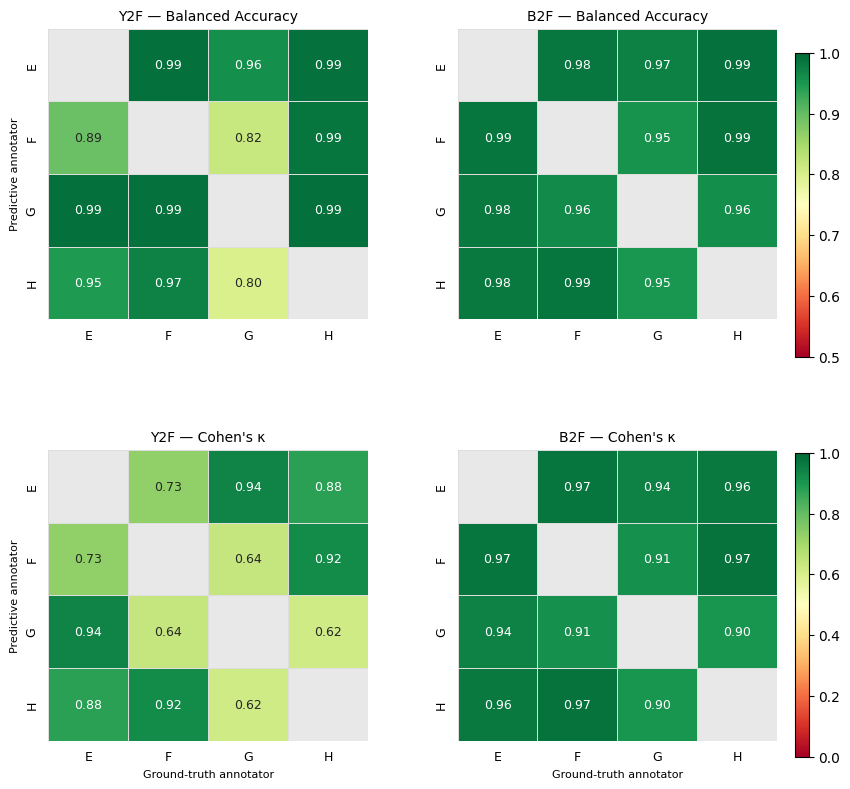

In [10]:
fig = plot_iaba_heatmap(
    pairs_df, OUTCOMES,
    save_path=RESULTS_DIR / 'iaba_heatmap.pdf',
)
plt.show()

## 4. Error diagnostic

The bounds table in Sec. 3 shows that all three bounds are consistently lower for Y2F than for B2F, indicating that annotators disagree more on the yellow grooming outcome. Two sources explain this:

- **Bout boundary ambiguity (both outcomes).** Frames at the onset or offset of grooming (approaching, withdrawing) are genuinely ambiguous — annotators must judge whether contact has started or ended.

- **Salience of the colour marking (Y2F only).** Ant bodies are naturally yellow/amber, so the yellow dot blends with the ant's own coloration and warm background tones. Blue is unnatural in this context and stands out immediately, making the blue-marked ant easy to track and localise. This compounds boundary ambiguity: when the nestmate is hard to find, the perceived start/end of contact is less crisp.

The plots below sample frames where the two most-disagreeing annotators for each outcome disagree, with ±2 frames of temporal context.

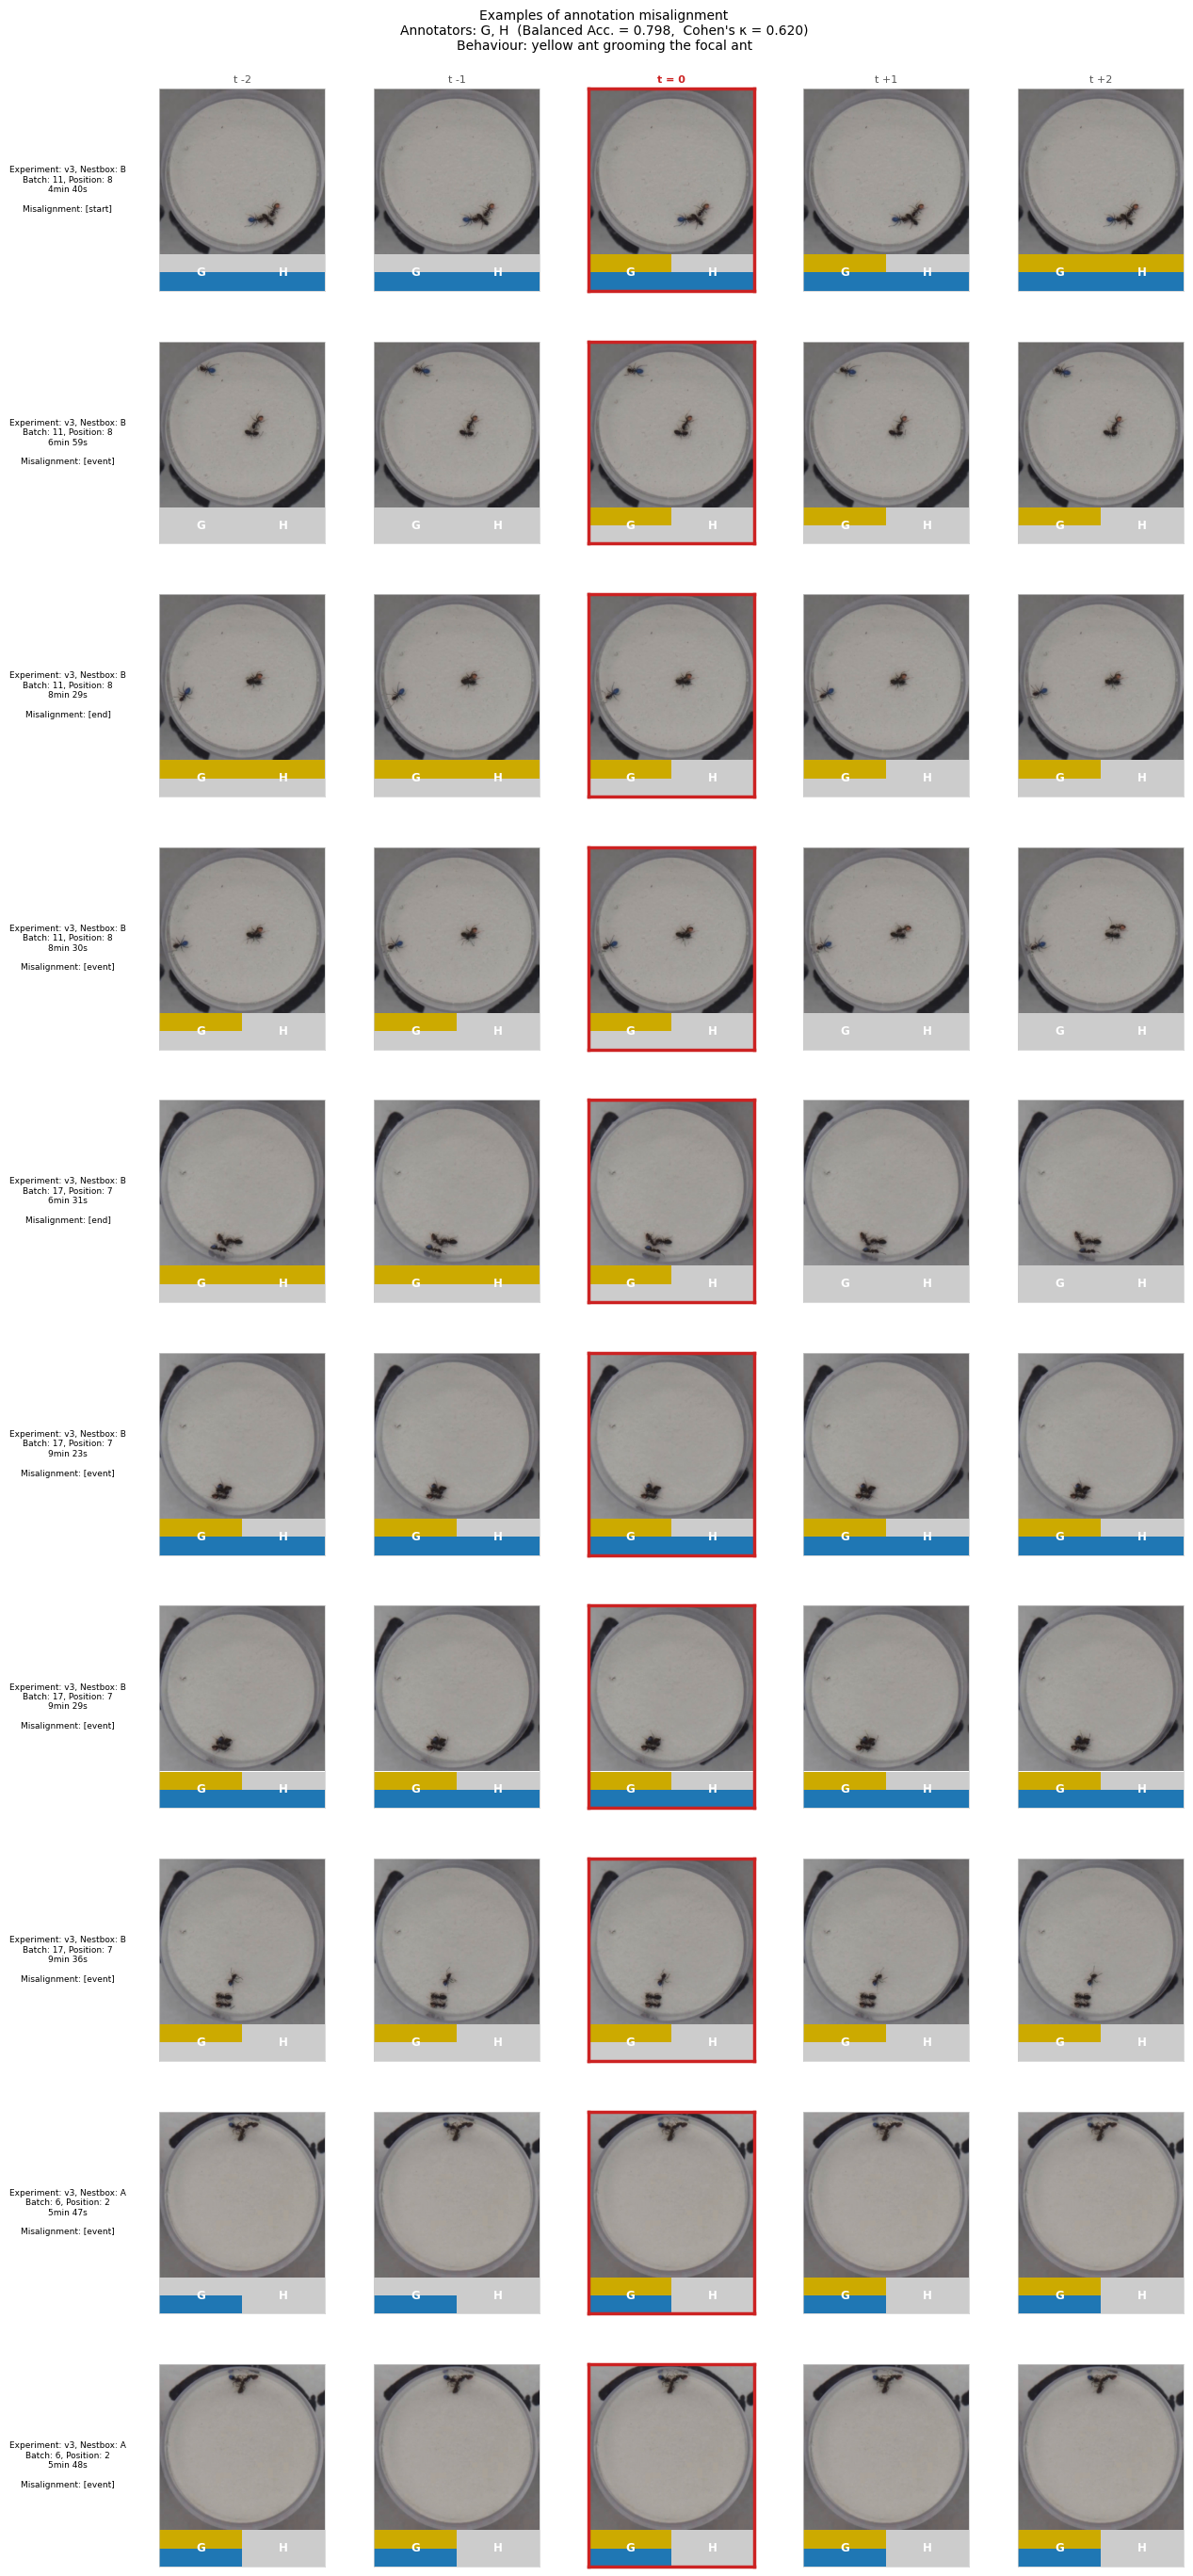

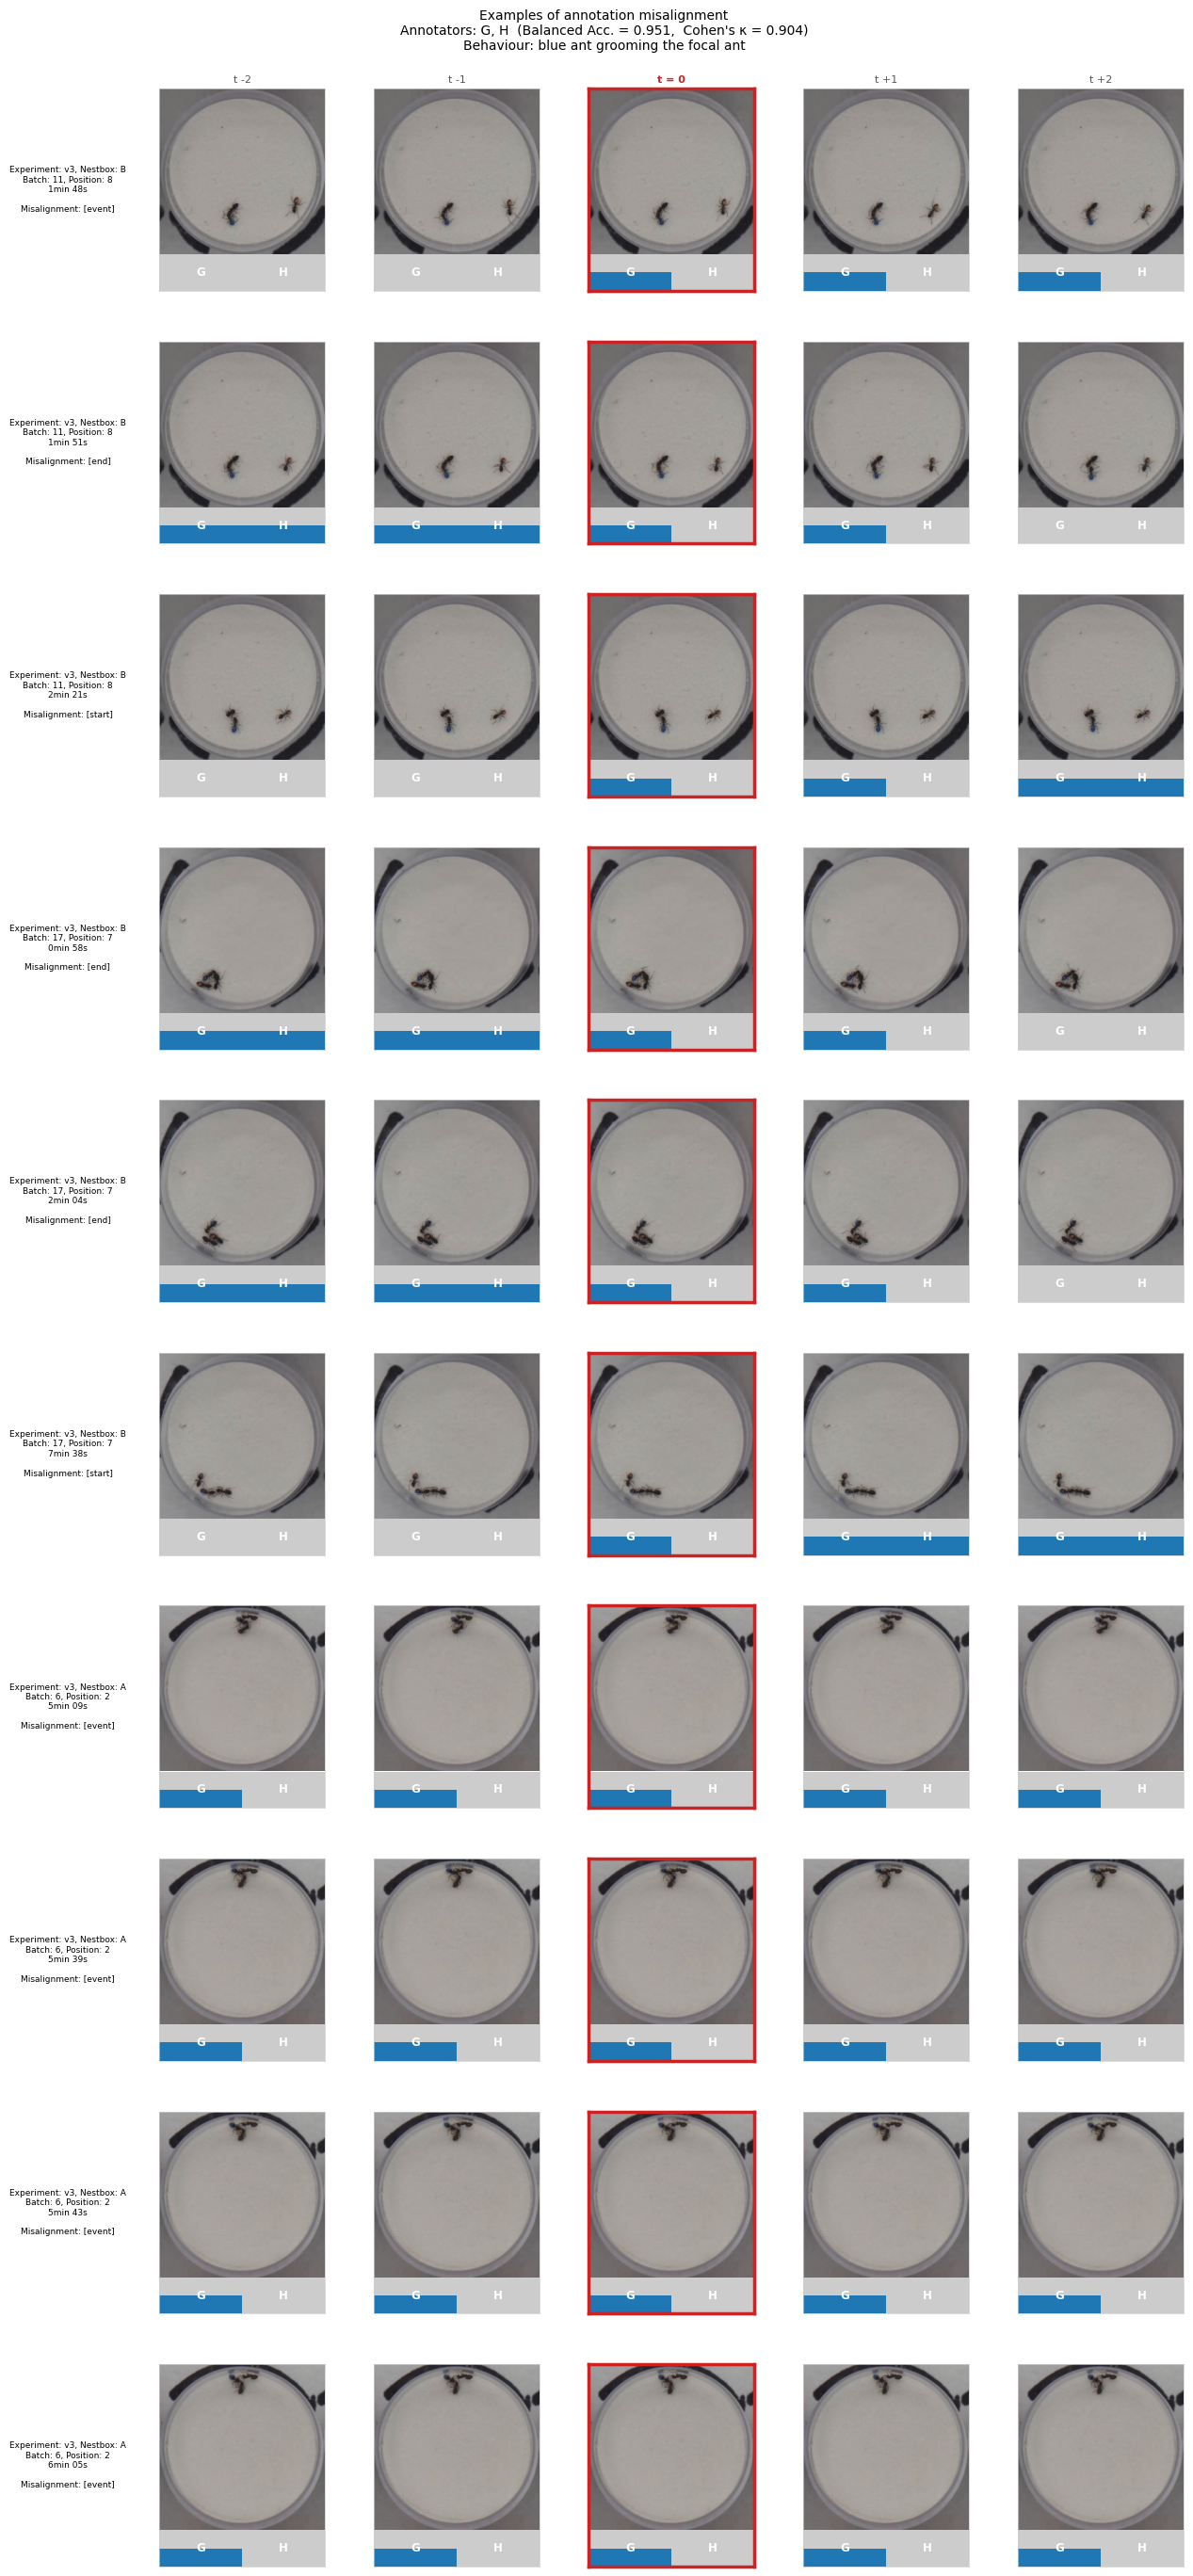

In [11]:
for viz_out in OUTCOMES:
    fig = plot_disagreement_temporal(
        labels, pairs_df, FRAME_ROOT,
        outcome=viz_out,
        k=N_DISAGREE_EXAMPLES,
        exp_df=exp_df,
        save_path=RESULTS_DIR / f'disagreement_{viz_out}.pdf',
    )
    if fig is not None:
        plt.show()